## Exploring the variance in cross validation and how the dependence of the folds affects it.
### This notebook aims to demonstrate how the variance in cross validation schemes is reduced due to the dependence between the folds of the cross validation. For example, for a 10 Kfolds scheme only 10% of the training samples are different between folds.


Initial idea and implementation by Kaustubh Patil. Adapted and commented by Nicolás Nieto

In [12]:
# Imports
import warnings
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score

warnings

<module 'warnings' from '/home/nnieto/.local/share/uv/python/cpython-3.13.9-linux-x86_64-gnu/lib/python3.13/warnings.py'>

In [13]:
# -----------------------------
# 1. Generate a large dataset
# -----------------------------
X_big, y_big = make_classification(
    n_samples=100_000,
    n_features=40,
    n_informative=30,
    n_redundant=5,
    n_repeated=0,
    n_classes=2,
    random_state=42,
)

In [14]:
# -----------------------------
# 2. Sample 1,000 examples
# -----------------------------
rng = np.random.RandomState(42)
idx_small = rng.choice(X_big.shape[0], size=1_000, replace=False)

X_small = X_big[idx_small]
y_small = y_big[idx_small]

# 10 times 10-fold CV
rkf = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=42)
fold_splits = list(rkf.split(X_small, y=y_small))

clf = LogisticRegressionCV(max_iter=1000, l1_ratios=(0,), use_legacy_attributes=False)

In [15]:
# -----------------------------
# 3. Standard repeated CV
# -----------------------------
acc_standard = []

for train_idx, test_idx in fold_splits:
    X_train, X_test = X_small[train_idx], X_small[test_idx]
    y_train, y_test = y_small[train_idx], y_small[test_idx]

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc_standard.append(accuracy_score(y_test, y_pred))


In [16]:
# -----------------------------
# 4. Fixed test folds, resampled training
#    with GLOBAL no-reuse across all folds/repeats
# -----------------------------
acc_resampled_unique = []

# Exclude the original 1,000-sample subset entirely from the resampling pool
eligible_mask = np.ones(X_big.shape[0], dtype=bool)
eligible_mask[idx_small] = False
eligible_idx = np.where(eligible_mask)[0]

# Shuffle once and consume unique samples sequentially
eligible_idx = rng.permutation(eligible_idx)

train_size = 900
n_resamples = len(fold_splits)
needed_total = train_size * n_resamples

assert needed_total <= len(eligible_idx)

cursor = 0
used_samples = set()

for train_idx, test_idx in fold_splits:
    X_test = X_small[test_idx]
    y_test = y_small[test_idx]

    sampled_train_idx = eligible_idx[cursor : cursor + train_size]
    cursor += train_size

    # Sanity checks
    assert len(np.unique(sampled_train_idx)) == train_size
    assert used_samples.isdisjoint(sampled_train_idx.tolist())
    used_samples.update(sampled_train_idx.tolist())

    X_train = X_big[sampled_train_idx]
    y_train = y_big[sampled_train_idx]

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc_resampled_unique.append(accuracy_score(y_test, y_pred))

Number of test accuracies per method: 100
Number of globally unique resampled training samples used: 90000
Any reuse across resampled training sets?: False
Standard repeated CV        mean=0.8267, std=0.0352
Resampled train no-reuse    mean=0.8180, std=0.0366


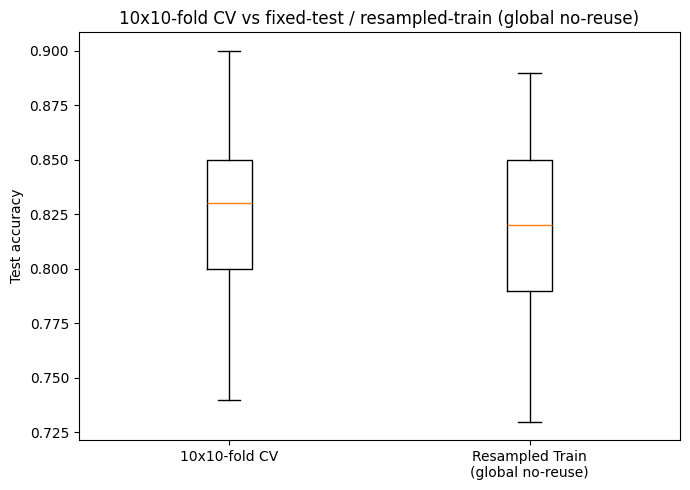

In [17]:
# -----------------------------
# 5. Summaries
# -----------------------------
print("Number of test accuracies per method:", len(acc_standard))
print("Number of globally unique resampled training samples used:", len(used_samples))
print(
    "Any reuse across resampled training sets?:",
    len(used_samples) != train_size * n_resamples,
)

print(
    f"Standard repeated CV        mean={np.mean(acc_standard):.4f}, std={np.std(acc_standard, ddof=1):.4f}"
)
print(
    f"Resampled train no-reuse    mean={np.mean(acc_resampled_unique):.4f}, std={np.std(acc_resampled_unique, ddof=1):.4f}"
)

# -----------------------------
# 6. Boxplot
# -----------------------------
plt.figure(figsize=(7, 5))
plt.boxplot(
    [acc_standard, acc_resampled_unique],
    tick_labels=["10x10-fold CV", "Resampled Train\n(global no-reuse)"],
)
plt.ylabel("Test accuracy")
plt.title("10x10-fold CV vs fixed-test / resampled-train (global no-reuse)")
plt.tight_layout()
plt.show()

## How to correct it?
### The Nadeau-Bengio corrections is aims to correct the variance for the t-test
 Further read: https://link.springer.com/article/10.1023/A:1024068626366

In [ ]:
def nadeau_bengio_variance(errors, n_train, n_test):
    errors = np.array(errors)
    K = len(errors)

    mean_error = np.mean(errors)
    s2 = np.var(errors, ddof=1)
    nb_correction = 1.0 / K + n_test / n_train
    var_nb = nb_correction * s2
    se_nb = np.sqrt(var_nb)

    return mean_error, var_nb, se_nb


mean_error, var_nb, se_nb = nadeau_bengio_variance(acc_resampled_unique, 900, 100)

print(f"Resampled train no-reuse    mean={mean_error:.4f}, std={se_nb:.4f}")


0.1211111111111111
Resampled train no-reuse    mean=0.8180, std=0.0127
